# Taller B3-T4 — Redes Neuronales para Forecasting
## Ventana entrada: 90 dias | Ventana salida: 1 dias

- **Parte 1 — Competicion**: entrenar y comparar modelos sobre log-retornos en bruto
- **Parte 2 — Investigacion**: aplicar preprocesado del Taller B3-T1 (Lopez de Prado) y evaluar su efecto


In [1]:
VENTANA_ENTRADA = 90   # dias de entrada
VENTANA_SALIDA  = 1   # dias de salida (promedio)


In [ ]:
#Ejecutar solo si se quiere entrenar en GPU 
import subprocess, sys, os

# ── Instalar PyTorch con CUDA si no esta disponible ──────────────────
try:
    import torch
    if not torch.cuda.is_available():
        raise RuntimeError('torch sin CUDA')
except (ImportError, RuntimeError):
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'torch', '--index-url', 'https://download.pytorch.org/whl/cu128'
    ])
    import torch

# ── Cambiar el backend de Keras a torch ANTES de importar keras ───────
os.environ['KERAS_BACKEND'] = 'torch'

# ── Verificar GPU ─────────────────────────────────────────────────────
import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {gpu_name}  ({vram_gb:.1f} GB VRAM)')
    print(f'CUDA: {torch.version.cuda}  |  PyTorch: {torch.__version__}')
    print('Backend Keras: torch  ->  entrenamiento en GPU activado')
else:
    print('AVISO: GPU no disponible, entrenando en CPU')

GPU: NVIDIA GeForce RTX 5080 Laptop GPU  (17.1 GB VRAM)
CUDA: 12.8  |  PyTorch: 2.11.0+cu128
Backend Keras: torch  ->  entrenamiento en GPU activado


In [3]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity
from statsmodels.tsa.stattools import adfuller
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from utilidades.carga_datos  import cargar_retornos, create_time_series_data, dividir_datos, aplanar_X
from utilidades.modelos      import (
    construir_dense, construir_dense_v2, construir_dense_v3,
    construir_dense_v4, construir_dense_v5, construir_dense_v6,
    construir_recurrente, construir_recurrente_v2, construir_recurrente_v3,
    construir_recurrente_v4, construir_recurrente_v5, construir_recurrente_v6,
    construir_conv1d, construir_conv1d_v2, construir_conv1d_v3,
    construir_conv1d_v4, construir_conv1d_v5, construir_conv1d_v6,
    construir_mixto,
)
from utilidades.evaluacion   import evaluar_modelo, evaluar_sklearn, evaluar_buyhold, guardar_resultados
from utilidades.graficos     import graficar_convergencia, graficar_barras_mae
CALLBACKS = [
    EarlyStopping(patience=10000, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.1, patience=500, verbose=1),
]

---
# PARTE 1 — Competicion
Modelos sobre log-retornos en bruto. Metrica: MAE medio sobre 23 activos.


## 1.1 Carga de datos

In [4]:
retornos = cargar_retornos()
X, y = create_time_series_data(retornos, VENTANA_ENTRADA, VENTANA_SALIDA)
print(f'X: {X.shape}  |  y: {y.shape}')
X_train, X_val, X_test, y_train, y_val, y_test = dividir_datos(X, y)
X_train_plano = aplanar_X(X_train)
X_val_plano   = aplanar_X(X_val)
X_test_plano  = aplanar_X(X_test)
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


X: (16100, 90, 23)  |  y: (16100, 23)
Train: (13765, 90, 23)  Val: (725, 90, 23)  Test: (1610, 90, 23)


## 1.2 Baselines

In [5]:
reg_lineal = LinearRegression()
reg_lineal.fit(X_train_plano, y_train)
resultado_lineal = evaluar_sklearn(
    reg_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal')
resultado_bah = evaluar_buyhold(y_train, y_val, y_test)
print(pd.DataFrame([resultado_lineal, resultado_bah]).set_index('modelo').round(6))


            mae_train   mae_val  mae_test  n_params
modelo                                             
Lineal       0.011085  0.010643  0.014020         0
BuyAndHold   0.011700  0.009218  0.012271         0


## 1.3 Modelos Dense (MLP)

In [12]:
modelo_dense = construir_dense(X_train_plano.shape[1], y_train.shape[1])
modelo_dense.summary()
hist_dense = modelo_dense.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=200, batch_size=64,   verbose=1)

Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 256)            │       530,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 566,039 (2.16 MB)

 Trainable params: 566,039 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0120 - val_loss: 0.0092
Epoch 2/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 3/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 4/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0117 - val_loss: 0.0092
Epoch 5/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0116 - val_loss: 0.0093
Epoch 6/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0115 - val_loss: 0.0093
Epoch 7/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0115 - val_loss: 0.0093
Epoch 8/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0114 - val_loss: 0.0093
Epoch 9/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0114 - val_loss: 0.0092
Epoch 10/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0113 - val_loss: 0.0093
Epoch 11/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0112 - val_loss: 0.0093
Epoch 12/200
216/216 ━━━━━━━━━━━━━━━━━━━

{'modelo': 'Dense', 'mae_train': 0.007442423300042927, 'mae_val': 0.009805501487984784, 'mae_test': 0.012778978572520769, 'n_params': 566039}


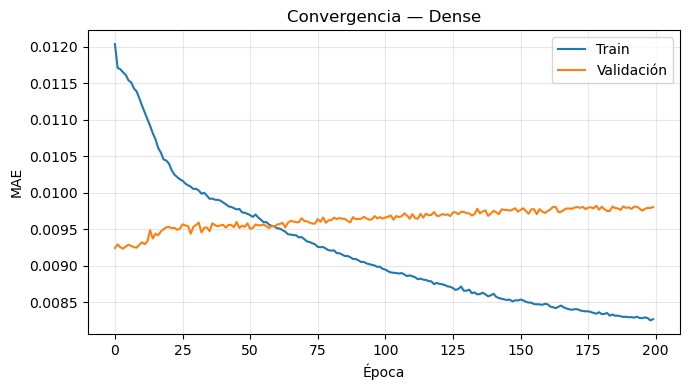

In [ ]:
graficar_convergencia(hist_dense, 'Dense')
resultado_dense = evaluar_modelo(modelo_dense, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense)

### Dense v2 -- 3 capas estrechas (128->64->32), Dropout 0.3

In [14]:
modelo_dense_v2 = construir_dense_v2(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_v2.summary()
hist_dense_v2 = modelo_dense_v2.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=150, batch_size=64,   verbose=1)

Model: "Dense_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │       265,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,183 (1.05 MB)

 Trainable params: 276,183 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0119 - val_loss: 0.0092
Epoch 2/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 3/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 4/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 5/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0117 - val_loss: 0.0092
Epoch 6/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0117 - val_loss: 0.0092
Epoch 7/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 8/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0117 - val_loss: 0.0092
Epoch 9/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0117 - val_loss: 0.0092
Epoch 10/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0117 - val_loss: 0.0092
Epoch 11/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0092
Epoch 12/150
216/216 ━━━━━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

{'modelo': 'Dense_v2', 'mae_train': 0.00964032388518741, 'mae_val': 0.009609909478836616, 'mae_test': 0.012673669874348753, 'n_params': 276183}


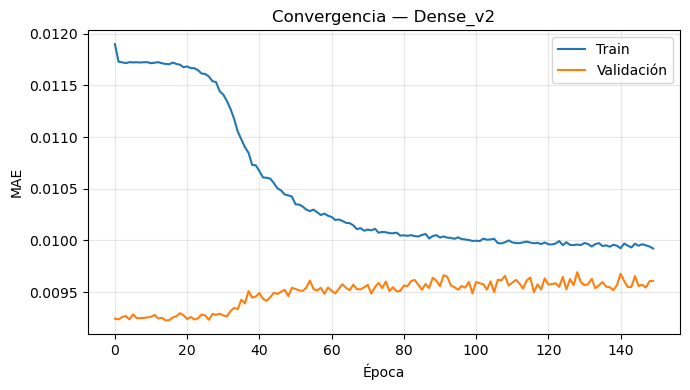

In [ ]:
graficar_convergencia(hist_dense_v2, 'Dense_v2')
resultado_dense_v2 = evaluar_modelo(modelo_dense_v2, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v2')
print(resultado_dense_v2)

### Dense v3 -- 4 capas anchas (512->256->128->64), LR=1e-4

In [ ]:
modelo_dense_v3 = construir_dense_v3(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_v3.summary()
hist_dense_v3 = modelo_dense_v3.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=100, batch_size=64,   verbose=1)

Model: "Dense_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 512)            │     1,060,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,234,327 (4.71 MB)

 Trainable params: 1,234,327 (4.71 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0119 - val_loss: 0.0092 - learning_rate: 1.0000e-04
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0117 - val_loss: 0.0092 - learning_rate: 1.0000e-04
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0092 - learning_rate: 1.0000e-04
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0092 - learning_rate: 1.0000e-04
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0116 - val_loss: 0.0092 - learning_rate: 1.0000e-04
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0115 - val_loss: 0.0092 - learning_rate: 1.0000e-04
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0114 - val_loss: 0.0092 - learning_rate: 1.0000e-04
Epoch 8/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0112 - val_loss: 0.0093 - learning_rate: 1.0000e-04
Epoch 9/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0110 - val_loss:

KeyboardInterrupt: 

{'modelo': 'Dense_v3', 'mae_train': 0.01167553797831789, 'mae_val': 0.00923975470020243, 'mae_test': 0.012292671042912788, 'n_params': 1234327}


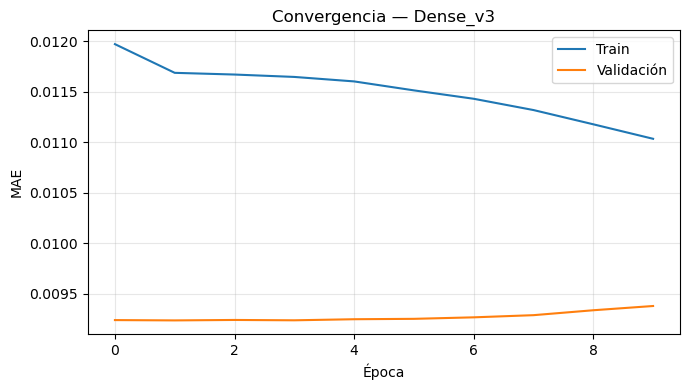

In [ ]:
graficar_convergencia(hist_dense_v3, 'Dense_v3')
resultado_dense_v3 = evaluar_modelo(modelo_dense_v3, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v3')
print(resultado_dense_v3)

### Dense v4 -- 2 capas con regularizacion L2 (128->64)

In [ ]:
modelo_dense_v4 = construir_dense_v4(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_v4.summary()
hist_dense_v4 = modelo_dense_v4.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=100, batch_size=64,   verbose=1)

Model: "Dense_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       265,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,839 (1.05 MB)

 Trainable params: 274,839 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0210 - val_loss: 0.0098 - learning_rate: 0.0010
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0119 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0117 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0117 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 5/100
204/216 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0117
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0117 - val_loss: 0.0092 - learning_rate: 5.0000e-04
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0117 - val_loss: 0.0092 - learning_rate: 5.0000e-04
Epoch 8/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0117 - val_loss: 0.0

{'modelo': 'Dense_v4', 'mae_train': 0.011716718378058356, 'mae_val': 0.00924028757965777, 'mae_test': 0.012285950740214251, 'n_params': 274839}


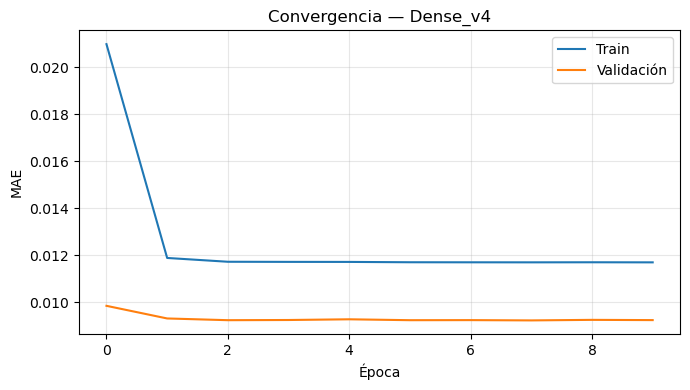

In [ ]:
graficar_convergencia(hist_dense_v4, 'Dense_v4')
resultado_dense_v4 = evaluar_modelo(modelo_dense_v4, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v4')
print(resultado_dense_v4)

### Dense v5 -- 1 capa oculta grande (256) con activacion tanh

In [ ]:
modelo_dense_v5 = construir_dense_v5(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_v5.summary()
hist_dense_v5 = modelo_dense_v5.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=100, batch_size=64,   verbose=1)

Model: "Dense_v5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 256)            │       530,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,087 (2.05 MB)

 Trainable params: 536,087 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0193 - val_loss: 0.0109 - learning_rate: 0.0010
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0129 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0118 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0116 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 5/100
209/216 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0113
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0115 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0113 - val_loss: 0.0097 - learning_rate: 5.0000e-04
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0112 - val_loss: 0.0097 - learning_rate: 5.0000e-04
Epoch 8/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0112 - val_loss: 0.0

{'modelo': 'Dense_v5', 'mae_train': 0.012749441967723037, 'mae_val': 0.010882893230139495, 'mae_test': 0.014511684823170445, 'n_params': 536087}


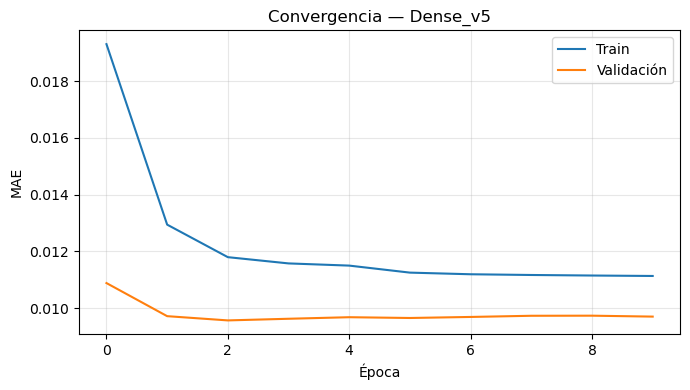

In [ ]:
graficar_convergencia(hist_dense_v5, 'Dense_v5')
resultado_dense_v5 = evaluar_modelo(modelo_dense_v5, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v5')
print(resultado_dense_v5)

### Dense v6 -- arquitectura piramidal inversa (32->64->128), activacion elu

In [ ]:
modelo_dense_v6 = construir_dense_v6(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_v6.summary()
hist_dense_v6 = modelo_dense_v6.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=100, batch_size=64,   verbose=1)

Model: "Dense_v6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 32)             │        66,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,671 (311.21 KB)

 Trainable params: 79,671 (311.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0130 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0119 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0119 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0118 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 5/100
203/216 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0116
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0117 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0116 - val_loss: 0.0094 - learning_rate: 5.0000e-04
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0115 - val_loss: 0.0094 - learning_rate: 5.0000e-04
Epoch 8/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0115 - val_loss: 0.0

{'modelo': 'Dense_v6', 'mae_train': 0.01182499418731753, 'mae_val': 0.009361643104098186, 'mae_test': 0.012401838731894887, 'n_params': 79671}


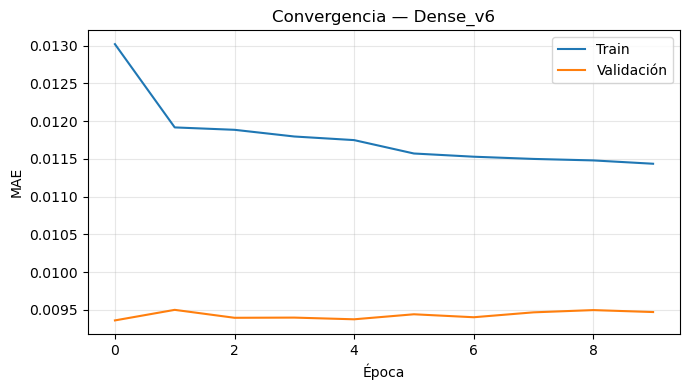

In [ ]:
graficar_convergencia(hist_dense_v6, 'Dense_v6')
resultado_dense_v6 = evaluar_modelo(modelo_dense_v6, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v6')
print(resultado_dense_v6)

## 1.4 Modelos Recurrentes (LSTM / GRU)

In [ ]:
modelo_lstm = construir_recurrente(X_train.shape[1:], y_train.shape[1])
modelo_lstm.summary()
hist_lstm = modelo_lstm.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,023 (93.84 KB)

 Trainable params: 24,023 (93.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 0.0119 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.0118 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.0118 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 5/100
215/216 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0118
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
216/216 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 5.0000e-04
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 5.0000e-04
Epoch 8/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0117 - val

{'modelo': 'LSTM', 'mae_train': 0.011808109767611683, 'mae_val': 0.009344719703355736, 'mae_test': 0.012403125116684207, 'n_params': 24023}


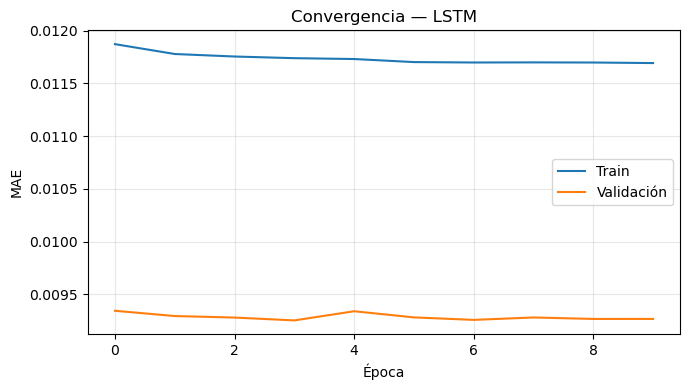

In [ ]:
graficar_convergencia(hist_lstm, 'LSTM')
resultado_lstm = evaluar_modelo(modelo_lstm, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM')
print(resultado_lstm)

### Recurrente v2 -- 2 capas LSTM apiladas (64->32)

In [15]:
modelo_lstm_v2 = construir_recurrente_v2(X_train.shape[1:], y_train.shape[1])
modelo_lstm_v2.summary()
hist_lstm_v2 = modelo_lstm_v2.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
  1/216 ━━━━━━━━━━━━━━━━━━━━ 1:21 381ms/step - loss: 0.0110

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


216/216 ━━━━━━━━━━━━━━━━━━━━ 25s 113ms/step - loss: 0.0118 - val_loss: 0.0093
Epoch 2/100
195/216 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0118

KeyboardInterrupt: 

In [ ]:
graficar_convergencia(hist_lstm_v2, 'LSTM_v2')
resultado_lstm_v2 = evaluar_modelo(modelo_lstm_v2, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM_v2')
print(resultado_lstm_v2)

### Recurrente v3 -- GRU bidireccional

In [16]:
modelo_bigru = construir_recurrente_v3(X_train.shape[1:], y_train.shape[1])
modelo_bigru.summary()
hist_bigru = modelo_bigru.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "BiGRU_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 64)             │        10,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,439 (48.59 KB)

 Trainable params: 12,439 (48.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
 12/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0138

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\backend\torch\rnn.py:853: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, h_n = torch._VF.gru(


216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0123 - val_loss: 0.0094
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0119 - val_loss: 0.0093
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0118 - val_loss: 0.0094
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0118 - val_loss: 0.0093
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0118 - val_loss: 0.0093
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0117 - val_loss: 0.0094
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 8/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 9/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0117 - val_loss: 0.0095
Epoch 10/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 11/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 12/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 

{'modelo': 'BiGRU_v3', 'mae_train': 0.011582749983968327, 'mae_val': 0.00935050647444267, 'mae_test': 0.012532641120525424, 'n_params': 12439}


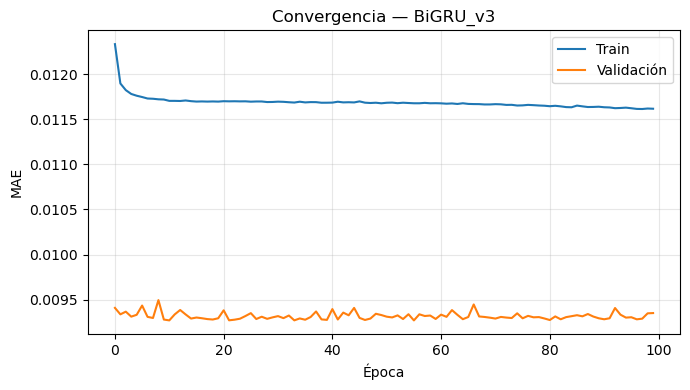

In [17]:
graficar_convergencia(hist_bigru, 'BiGRU_v3')
resultado_bigru = evaluar_modelo(modelo_bigru, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='BiGRU_v3')
print(resultado_bigru)

### Recurrente v4 -- LSTM + Dense intermedia (64 LSTM -> 32 Dense -> salida)

In [ ]:
modelo_lstm_v4 = construir_recurrente_v4(X_train.shape[1:], y_train.shape[1])
modelo_lstm_v4.summary()
hist_lstm_v4 = modelo_lstm_v4.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_lstm_v4, 'LSTM_v4')
resultado_lstm_v4 = evaluar_modelo(modelo_lstm_v4, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM_v4')
print(resultado_lstm_v4)

### Recurrente v5 -- LSTM 128 unidades con recurrent_dropout, LR=1e-4

In [ ]:
modelo_lstm_v5 = construir_recurrente_v5(X_train.shape[1:], y_train.shape[1])
modelo_lstm_v5.summary()
hist_lstm_v5 = modelo_lstm_v5.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_lstm_v5, 'LSTM_v5')
resultado_lstm_v5 = evaluar_modelo(modelo_lstm_v5, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM_v5')
print(resultado_lstm_v5)

### Recurrente v6 -- 2 capas GRU apiladas (64->32)

In [ ]:
modelo_gru_v6 = construir_recurrente_v6(X_train.shape[1:], y_train.shape[1])
modelo_gru_v6.summary()
hist_gru_v6 = modelo_gru_v6.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_gru_v6, 'GRU_v6')
resultado_gru_v6 = evaluar_modelo(modelo_gru_v6, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='GRU_v6')
print(resultado_gru_v6)

## 1.5 Modelos Conv1D

In [ ]:
modelo_conv = construir_conv1d(X_train.shape[1:], y_train.shape[1])
modelo_conv.summary()
hist_conv = modelo_conv.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_conv, 'Conv1D')
resultado_conv = evaluar_modelo(modelo_conv, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D')
print(resultado_conv)

### Conv1D v2 -- 1 capa Conv1D + Flatten (modelo mas simple)

In [ ]:
modelo_conv_v2 = construir_conv1d_v2(X_train.shape[1:], y_train.shape[1])
modelo_conv_v2.summary()
hist_conv_v2 = modelo_conv_v2.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_conv_v2, 'Conv1D_v2')
resultado_conv_v2 = evaluar_modelo(modelo_conv_v2, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v2')
print(resultado_conv_v2)

### Conv1D v3 -- 3 capas Conv1D (64->32->16) + GlobalAveragePooling

In [ ]:
modelo_conv_v3 = construir_conv1d_v3(X_train.shape[1:], y_train.shape[1])
modelo_conv_v3.summary()
hist_conv_v3 = modelo_conv_v3.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_conv_v3, 'Conv1D_v3')
resultado_conv_v3 = evaluar_modelo(modelo_conv_v3, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v3')
print(resultado_conv_v3)

### Conv1D v4 -- Conv1D dilatada (dilation_rate=2), campo receptivo ampliado

In [ ]:
modelo_conv_v4 = construir_conv1d_v4(X_train.shape[1:], y_train.shape[1])
modelo_conv_v4.summary()
hist_conv_v4 = modelo_conv_v4.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_conv_v4, 'Conv1D_v4')
resultado_conv_v4 = evaluar_modelo(modelo_conv_v4, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v4')
print(resultado_conv_v4)

### Conv1D v5 -- SeparableConv1D (menos parametros, mismo campo receptivo)

In [ ]:
modelo_conv_v5 = construir_conv1d_v5(X_train.shape[1:], y_train.shape[1])
modelo_conv_v5.summary()
hist_conv_v5 = modelo_conv_v5.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_conv_v5, 'Conv1D_v5')
resultado_conv_v5 = evaluar_modelo(modelo_conv_v5, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v5')
print(resultado_conv_v5)

### Conv1D v6 -- Conv1D + MaxPooling1D + Flatten

In [ ]:
modelo_conv_v6 = construir_conv1d_v6(X_train.shape[1:], y_train.shape[1])
modelo_conv_v6.summary()
hist_conv_v6 = modelo_conv_v6.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_conv_v6, 'Conv1D_v6')
resultado_conv_v6 = evaluar_modelo(modelo_conv_v6, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v6')
print(resultado_conv_v6)

## 1.6 Modelo Mixto (Conv1D + LSTM)

In [ ]:
modelo_mixto = construir_mixto(X_train.shape[1:], y_train.shape[1])
modelo_mixto.summary()
hist_mixto = modelo_mixto.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_mixto, 'Mixto')
resultado_mixto = evaluar_modelo(modelo_mixto, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Mixto')
print(resultado_mixto)


## 1.7 Resumen de competicion y guardado

In [ ]:
resultados_competicion = [
    resultado_lineal, resultado_bah,
    # Dense
    resultado_dense, resultado_dense_v2, resultado_dense_v3,
    resultado_dense_v4, resultado_dense_v5, resultado_dense_v6,
    # Recurrente
    resultado_lstm, resultado_lstm_v2, resultado_bigru,
    resultado_lstm_v4, resultado_lstm_v5, resultado_gru_v6,
    # Conv1D
    resultado_conv, resultado_conv_v2, resultado_conv_v3,
    resultado_conv_v4, resultado_conv_v5, resultado_conv_v6,
    # Mixto
    resultado_mixto,
]
graficar_barras_mae(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA)
guardar_resultados(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA, seccion='competicion')
display(pd.DataFrame(resultados_competicion).set_index('modelo').round(6))

---
# PARTE 2 — Investigacion
Preprocesado del Taller B3-T1 (Lopez de Prado):
1. **FFD** sobre log-retornos (Snippets 5.3-5.4, *Advances in Financial ML* 2018)
2. **Denoising Marchenko-Pastur** (*ML for Asset Managers* 2020)
3. **StandardScaler** ajustado solo sobre train


## 2.1 Diferenciacion fraccional (FFD)
Se aplica sobre **log-retornos** con ventana maxima de 500 pasos para
garantizar que siempre haya suficientes observaciones tras la transformacion.


In [ ]:
# ── Snippet 5.3: pesos FFD con ventana maxima ───────────────────────────
def get_weights_ffd(d, threshold=1e-5, max_width=None):
    """Pesos para diferenciacion fraccional FFD. max_width limita la ventana."""
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k); k += 1
        if max_width and len(w) >= max_width:
            break
    return np.array(w[::-1])

# ── Snippet 5.4: aplicar FFD ─────────────────────────────────────────────
def frac_diff_ffd(series, d, threshold=1e-5, max_width=None):
    """Aplica FFD a una pd.Series. max_width trunca la ventana de pesos."""
    if max_width is None:
        max_width = len(series)          # no exceder la longitud de la serie
    weights = get_weights_ffd(d, threshold, max_width=max_width)
    width = len(weights)
    if width > len(series):
        return pd.Series(dtype=float)    # serie demasiado corta
    vals = series.values
    # Usar lista en lugar de dict para evitar desalineacion con DatetimeIndex
    result_vals = [
        np.dot(weights, vals[i - width + 1 : i + 1])
        for i in range(width - 1, len(vals))
    ]
    return pd.Series(result_vals, index=series.index[width - 1:])

def encontrar_d_minimo(serie, d_values=None, threshold=1e-5, pvalue=0.05):
    """
    Encuentra el minimo d que hace la serie estacionaria (ADF p-value < pvalue).
    Usa max_width = min(500, len(serie)//2) para que la ventana de pesos nunca
    consuma la serie completa y siempre queden observaciones suficientes.
    """
    if d_values is None:
        d_values = np.arange(0.1, 1.01, 0.1).round(1)
    serie_limpia = serie.replace([np.inf, -np.inf], np.nan).dropna()
    max_w = min(500, len(serie_limpia) // 2)   # ventana maxima: 500 o mitad de la serie
    for d in d_values:
        serie_diff = frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
        serie_diff = serie_diff.replace([np.inf, -np.inf], np.nan).dropna()
        if len(serie_diff) < 20:
            continue
        try:
            adf_pval = adfuller(serie_diff, autolag='AIC')[1]
        except Exception:
            continue
        if adf_pval < pvalue:
            return d, frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
    # Fallback: d=1 (primera diferencia), siempre estacionaria para retornos
    return 1.0, frac_diff_ffd(serie_limpia, 1.0, threshold, max_width=max_w)


In [ ]:
# FFD aplicada directamente sobre log-retornos.
# max_width=500 garantiza que la ventana de pesos no consuma la serie entera.

d_values = np.arange(0.1, 1.01, 0.1).round(1)
retornos_ffd = {}
d_optimos = {}

for ticker in retornos.columns:
    d_opt, serie_ffd = encontrar_d_minimo(retornos[ticker], d_values)
    d_optimos[ticker] = d_opt
    retornos_ffd[ticker] = serie_ffd

df_ffd = pd.DataFrame(retornos_ffd).dropna()
df_ffd = df_ffd.loc[:, df_ffd.std() > 1e-10]  # eliminar columnas constantes

print('d optimos por activo:')
print(pd.Series(d_optimos).value_counts().sort_index())
print(f'\nForma tras FFD: {df_ffd.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(list(d_optimos.values()), bins=10, edgecolor='black')
axes[0].set_title('Distribucion de d optimo por activo')
axes[0].set_xlabel('d')
ticker_ej = retornos.columns[0]
axes[1].plot(retornos[ticker_ej].values[:500],  label='Log-retorno original', alpha=0.7)
axes[1].plot(df_ffd[ticker_ej].values[:500],    label=f'FFD (d={d_optimos[ticker_ej]})', alpha=0.7)
axes[1].set_title(f'Log-retorno vs FFD — {ticker_ej}')
axes[1].legend()
plt.tight_layout(); plt.show()


## 2.2 Denoising Marchenko-Pastur
Fuente: Lopez de Prado (2020). La funcion incluye fallbacks para casos
donde la matriz no converge numericamente.


In [ ]:
def mp_pdf(var, q, pts=1000):
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lmin, lmax, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt(np.maximum((lmax - x) * (x - lmin), 0))
    return x, pdf, lmax

def fit_kde(obs, bwidth=None, x=None):
    # bwidth adaptativo: 10% del rango de los datos
    if bwidth is None:
        r = obs.max() - obs.min()
        bwidth = max(0.01, r * 0.10)
    kde = KernelDensity(bandwidth=bwidth).fit(obs.reshape(-1, 1))
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    return x, np.exp(kde.score_samples(x.reshape(-1, 1)))

def err_pdfs(var, evals, q):
    if var <= 0:
        return 1e10
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    if lmax <= lmin:
        return 1e10
    x_mp, pdf_mp, _ = mp_pdf(var, q)
    _, pdf_kde = fit_kde(evals, x=x_mp)
    return float(np.sum((pdf_kde - pdf_mp) ** 2))

def find_max_eval(evals, q):
    # Normalizar eigenvalues para que el rango de busqueda sea significativo
    evals_flat = evals.flatten()
    evals_mean = evals_flat.mean()
    if evals_mean <= 0:
        evals_mean = 1.0
    evals_norm = evals_flat / evals_mean
    # Buscar var en [0.01, 3] sobre datos normalizados
    best_sse, best_var = np.inf, 1.0
    for var in np.linspace(0.01, 3.0, 60):
        sse = err_pdfs(var, evals_norm, q)
        if sse < best_sse:
            best_sse, best_var = sse, var
    # Refinamiento fino alrededor del mejor
    lo, hi = max(0.001, best_var * 0.5), best_var * 2.0
    try:
        from scipy.optimize import minimize_scalar
        res = minimize_scalar(err_pdfs, bounds=(lo, hi), method='bounded',
                              args=(evals_norm, q))
        if res.success and res.fun < best_sse:
            best_var = res.x
    except Exception:
        pass
    # lmax en escala original
    _, _, lmax_norm = mp_pdf(best_var, q)
    return lmax_norm * evals_mean

def denoised_corr(evals, evecs, n_signal):
    ev = evals.copy()
    noise = ev[n_signal:]
    if len(noise) > 0:
        ev[n_signal:] = noise.mean()
    corr = evecs @ np.diag(ev) @ evecs.T
    diag = np.sqrt(np.diag(corr))
    diag[diag == 0] = 1.0
    corr = corr / np.outer(diag, diag)
    np.fill_diagonal(corr, 1.0)
    return corr

def aplicar_denoising(returns_df):
    """
    Denoising Marchenko-Pastur sobre la matriz de covarianza.
    Devuelve (df_limpio, n_signal, lmax).
    """
    df = returns_df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(axis=1, how='any')
    df = df.loc[:, df.std() > 1e-10]

    if df.shape[1] < 2 or df.shape[0] < df.shape[1] + 5:
        return returns_df, 0, 1.0

    cov = df.cov().values
    if np.isnan(cov).any() or np.isinf(cov).any():
        return returns_df, 0, 1.0

    N = cov.shape[0]
    T = df.shape[0]
    q = T / N

    std = np.sqrt(np.diag(cov))
    std[std == 0] = 1.0
    corr = np.clip(cov / np.outer(std, std), -1, 1)
    np.fill_diagonal(corr, 1.0)

    try:
        evals, evecs = np.linalg.eigh(corr)
    except np.linalg.LinAlgError:
        print('AVISO: eigh no convergio, se devuelven datos sin denoising')
        return returns_df, 0, 1.0

    # eigh devuelve orden ascendente; invertir para descendente
    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]
    evals = np.maximum(evals, 1e-10)   # evitar eigenvalues negativos por precision

    lmax = find_max_eval(evals.reshape(-1, 1), q)
    n_signal = max(1, min(N - 1, int(np.sum(evals > lmax))))

    corr_clean = denoised_corr(evals, evecs, n_signal)
    corr_clean = np.clip(corr_clean, -1, 1)
    np.fill_diagonal(corr_clean, 1.0)

    cov_clean = corr_clean * np.outer(std, std)
    cov_clean = (cov_clean + cov_clean.T) / 2 + 1e-6 * np.eye(N)

    try:
        L = np.linalg.cholesky(cov_clean)
        returns_clean = df.values @ np.linalg.inv(L).T
    except np.linalg.LinAlgError:
        print('AVISO: Cholesky no convergio, se devuelven datos sin transformar')
        returns_clean = df.values

    result = pd.DataFrame(returns_clean, index=df.index, columns=df.columns)
    for col in returns_df.columns:
        if col not in result.columns:
            result[col] = returns_df[col]
    return result[returns_df.columns], n_signal, lmax


In [ ]:
df_ffd_denoised, n_signal, lmax = aplicar_denoising(df_ffd)
print(f'Autovalores de senyal: {n_signal} / {df_ffd.shape[1]}')
print(f'Lambda_max (Marchenko-Pastur): {lmax:.4f}')

T, N = df_ffd.shape
corr_raw   = np.nan_to_num(df_ffd.corr().values, nan=0.0)
np.fill_diagonal(corr_raw, 1.0)
evals_raw   = np.sort(np.linalg.eigvalsh(corr_raw))[::-1]
corr_clean = np.nan_to_num(df_ffd_denoised.corr().values, nan=0.0)
np.fill_diagonal(corr_clean, 1.0)
evals_clean = np.sort(np.linalg.eigvalsh(corr_clean))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), evals_raw,   color='steelblue', alpha=0.7)
axes[0].axhline(lmax, color='red', linestyle='--', label=f'lambda_max={lmax:.2f}')
axes[0].set_title('Autovalores — antes del denoising'); axes[0].legend()
axes[1].bar(range(N), evals_clean, color='orange', alpha=0.7)
axes[1].set_title('Autovalores — despues del denoising')
plt.tight_layout(); plt.show()


## 2.3 Construccion de ventanas con datos preprocesados

In [ ]:
df_prep = df_ffd_denoised
print(f'Serie preprocesada: {df_prep.shape}')
X_p, y_p = create_time_series_data(df_prep, VENTANA_ENTRADA, VENTANA_SALIDA)
X_tr_p, X_val_p, X_ts_p, y_tr_p, y_val_p, y_ts_p = dividir_datos(X_p, y_p)
n_tr, v, ch = X_tr_p.shape
scaler = StandardScaler()
X_tr_flat  = scaler.fit_transform(X_tr_p.reshape(n_tr, -1))
X_val_flat = scaler.transform(X_val_p.reshape(X_val_p.shape[0], -1))
X_ts_flat  = scaler.transform(X_ts_p.reshape(X_ts_p.shape[0],  -1))
X_tr_3d  = X_tr_flat.reshape(n_tr, v, ch)
X_val_3d = X_val_flat.reshape(X_val_p.shape[0], v, ch)
X_ts_3d  = X_ts_flat.reshape(X_ts_p.shape[0],  v, ch)
print(f'Train: {X_tr_3d.shape}  Val: {X_val_3d.shape}  Test: {X_ts_3d.shape}')


## 2.4 Mejor modelo de Parte 1 re-entrenado con preprocesado

In [ ]:
df_comp = pd.DataFrame(resultados_competicion)
modelos_nn = ('Dense', 'LSTM', 'Conv1D', 'Mixto')
df_nn = df_comp[df_comp['modelo'].isin(modelos_nn)]
mejor_nombre = df_nn.loc[df_nn['mae_test'].idxmin(), 'modelo']
print(f'Mejor modelo Parte 1 (redes neuronales): {mejor_nombre}')
usa_plano = mejor_nombre in ('Dense', 'Lineal')
constructores_prep = {
    'Dense':  lambda: construir_dense(X_tr_flat.shape[1], y_tr_p.shape[1]),
    'LSTM':   lambda: construir_recurrente(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Conv1D': lambda: construir_conv1d(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Mixto':  lambda: construir_mixto(X_tr_3d.shape[1:], y_tr_p.shape[1]),
}
modelo_prep = constructores_prep[mejor_nombre]()
X_fit     = X_tr_flat  if usa_plano else X_tr_3d
X_fit_val = X_val_flat if usa_plano else X_val_3d
X_fit_ts  = X_ts_flat  if usa_plano else X_ts_3d
hist_prep = modelo_prep.fit(
    X_fit, y_tr_p,
    validation_data=(X_fit_val, y_val_p),
    epochs=100, batch_size=64,   verbose=1)
graficar_convergencia(hist_prep, f'{mejor_nombre} + FFD + Denoising')
resultado_prep = evaluar_modelo(
    modelo_prep, X_fit, y_tr_p,
    X_fit_val, y_val_p, X_fit_ts, y_ts_p,
    nombre=f'{mejor_nombre}_prep')
print(resultado_prep)


## 2.5 Comparativa con/sin preprocesado y guardado

In [ ]:
resultado_sin_prep = df_comp[df_comp['modelo'] == mejor_nombre].iloc[0].to_dict()
comparativa = pd.DataFrame([resultado_sin_prep, resultado_prep])\
    .set_index('modelo')[['mae_train','mae_val','mae_test','n_params']].round(6)
display(comparativa)
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
ax.bar(x - 0.2, [resultado_sin_prep['mae_train'],
                  resultado_sin_prep['mae_val'],
                  resultado_sin_prep['mae_test']], 0.35,
       label='Sin preprocesado', color='steelblue')
ax.bar(x + 0.2, [resultado_prep['mae_train'],
                  resultado_prep['mae_val'],
                  resultado_prep['mae_test']], 0.35,
       label='FFD + Denoising', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(['MAE Train', 'MAE Val', 'MAE Test'])
ax.set_ylabel('MAE')
ax.set_title(f'{mejor_nombre}: efecto preprocesado B3-T1\n'
             f'Entrada {VENTANA_ENTRADA}d / Salida {VENTANA_SALIDA}d')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
mejora = (resultado_sin_prep['mae_test'] - resultado_prep['mae_test']) / resultado_sin_prep['mae_test'] * 100
print(f'Variacion MAE test con preprocesado: {mejora:+.1f}%')
guardar_resultados([resultado_prep], VENTANA_ENTRADA, VENTANA_SALIDA, seccion='investigacion')
